# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)

## 1. Overview & Objectives
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
It presents transactions that occurred in two days, where we have **492 frauds out of 284,807 transactions**.

### Key Highlights:
- **Total Records**: 284,807 transactions
- **Features**: 31 columns (`Time`, `Amount`, `Class`, and 28 PCA-transformed features `V1` to `V28` due to confidentiality).
- **Class Imbalance**: Highly unbalanced, positive class (frauds) account for **0.1727%** of all transactions.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Plotting Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset & Data Quality Check

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check data types and missing values
print("Missing Values:")
print(df.isnull().sum().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)")

Missing Values:
0

Duplicate Rows: 1081 (0.38%)


## 3. Class Distribution Analysis
Analyzing the severe class imbalance between normal and fraudulent transactions.

Legitimate Transactions (0): 284315 (99.8273%)
Fraudulent Transactions (1): 492 (0.1727%)


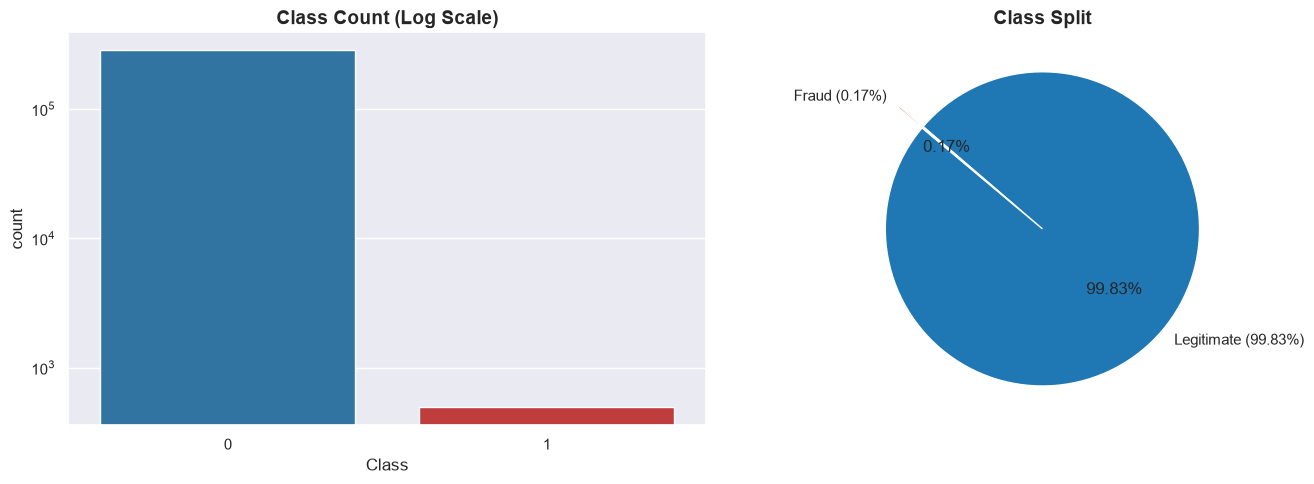

In [4]:
class_counts = df['Class'].value_counts()
print(f"Legitimate Transactions (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.4f}%)")
print(f"Fraudulent Transactions (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.4f}%)")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Class', hue='Class', data=df, ax=ax[0], palette=['#1f77b4', '#d62728'], legend=False)
ax[0].set_title('Class Count (Log Scale)', fontsize=14, fontweight='bold')
ax[0].set_yscale('log')

ax[1].pie(class_counts, labels=['Legitimate (99.83%)', 'Fraud (0.17%)'], autopct='%1.2f%%',
          explode=(0, 0.2), colors=['#1f77b4', '#d62728'], startangle=140)
ax[1].set_title('Class Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Analysis: Amount & Time
Comparing transaction amounts and timing between legitimate and fraudulent activities.

In [5]:
print("--- Legitimate Amount Statistics ---")
print(df[df['Class'] == 0]['Amount'].describe())
print("\n--- Fraudulent Amount Statistics ---")
print(df[df['Class'] == 1]['Amount'].describe())

--- Legitimate Amount Statistics ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraudulent Amount Statistics ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


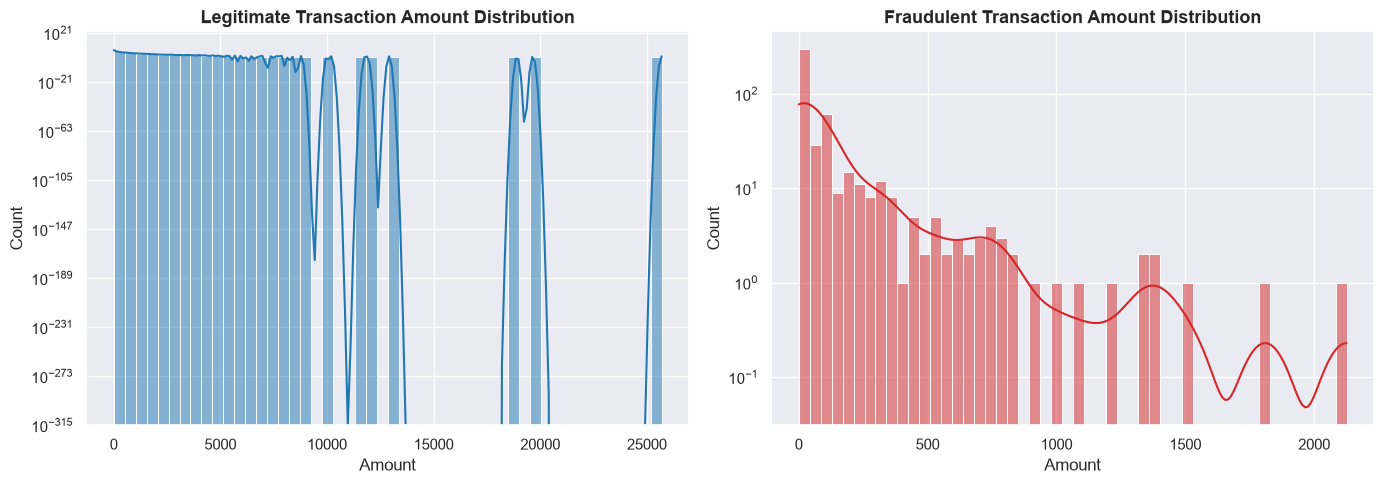

In [6]:
# Plot Amount Distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df['Class'] == 0]['Amount'], ax=ax[0], color='#1f77b4', bins=50, kde=True)
ax[0].set_title('Legitimate Transaction Amount Distribution', fontsize=13, fontweight='bold')
ax[0].set_yscale('log')

sns.histplot(df[df['Class'] == 1]['Amount'], ax=ax[1], color='#d62728', bins=50, kde=True)
ax[1].set_title('Fraudulent Transaction Amount Distribution', fontsize=13, fontweight='bold')
ax[1].set_yscale('log')
plt.tight_layout()
plt.show()

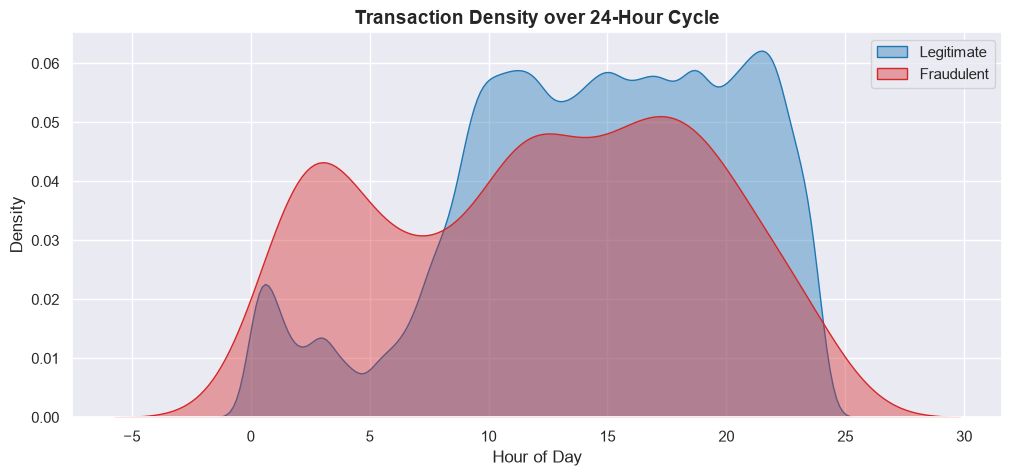

In [7]:
# Convert time (seconds) to hour of day (0-24)
df['Hour'] = (df['Time'] / 3600) % 24

fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Legitimate', color='#1f77b4', fill=True, alpha=0.4, ax=ax)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraudulent', color='#d62728', fill=True, alpha=0.4, ax=ax)
ax.set_title('Transaction Density over 24-Hour Cycle', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
plt.legend()
plt.show()

## 5. Correlation Analysis & Feature Importance
Examining which PCA components show the highest correlation with fraudulent activity.

In [8]:
corr = df.corr()
class_corr = corr['Class'].drop(['Class', 'Hour']).sort_values()

print("Top 5 Negatively Correlated Features with Class:")
print(class_corr.head(5))
print("\nTop 5 Positively Correlated Features with Class:")
print(class_corr.tail(5))

Top 5 Negatively Correlated Features with Class:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Top 5 Positively Correlated Features with Class:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


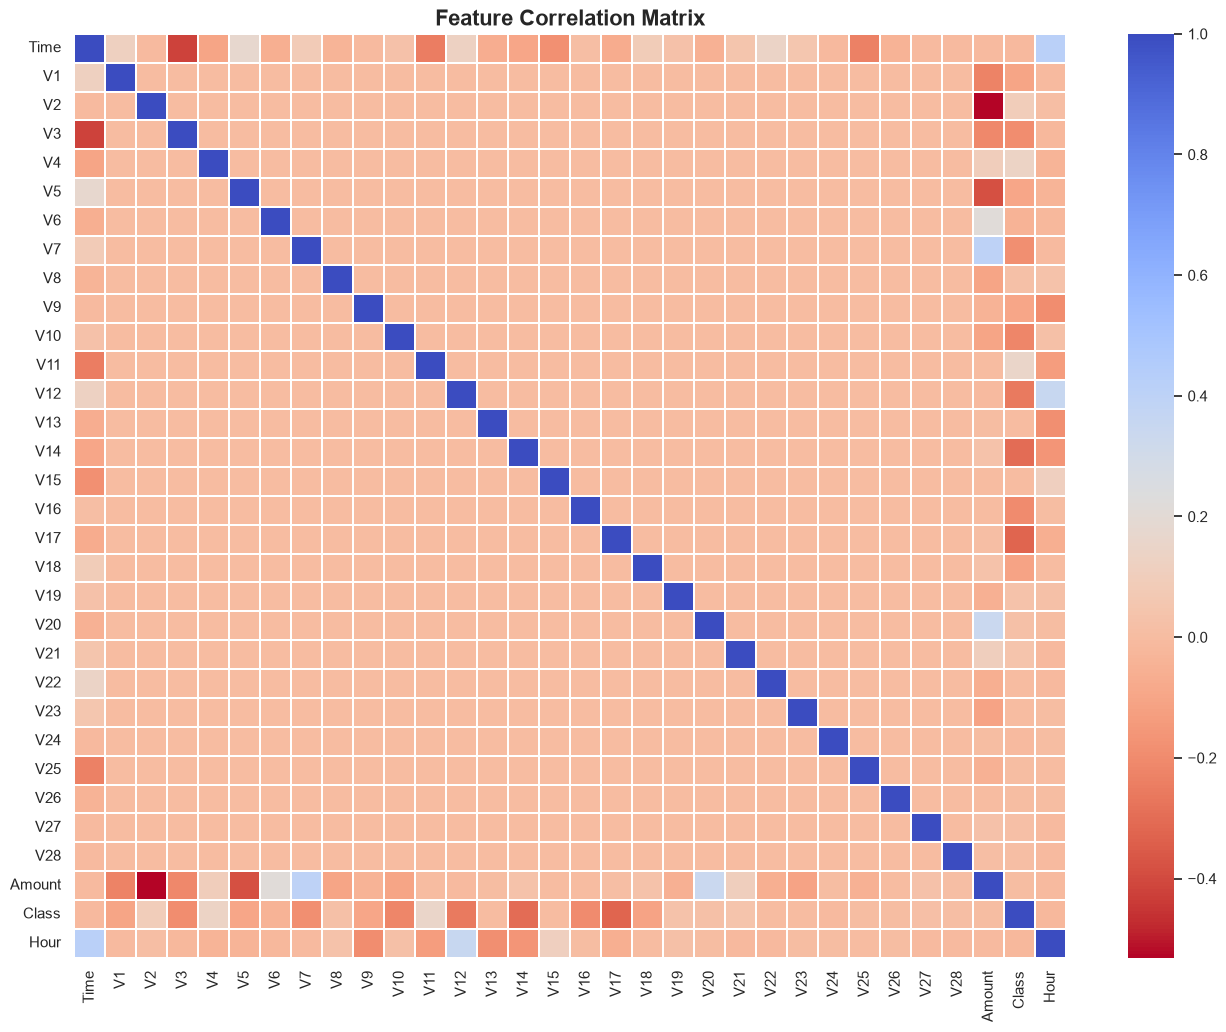

In [9]:
# Plot Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm_r', annot=False, linewidths=0.1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

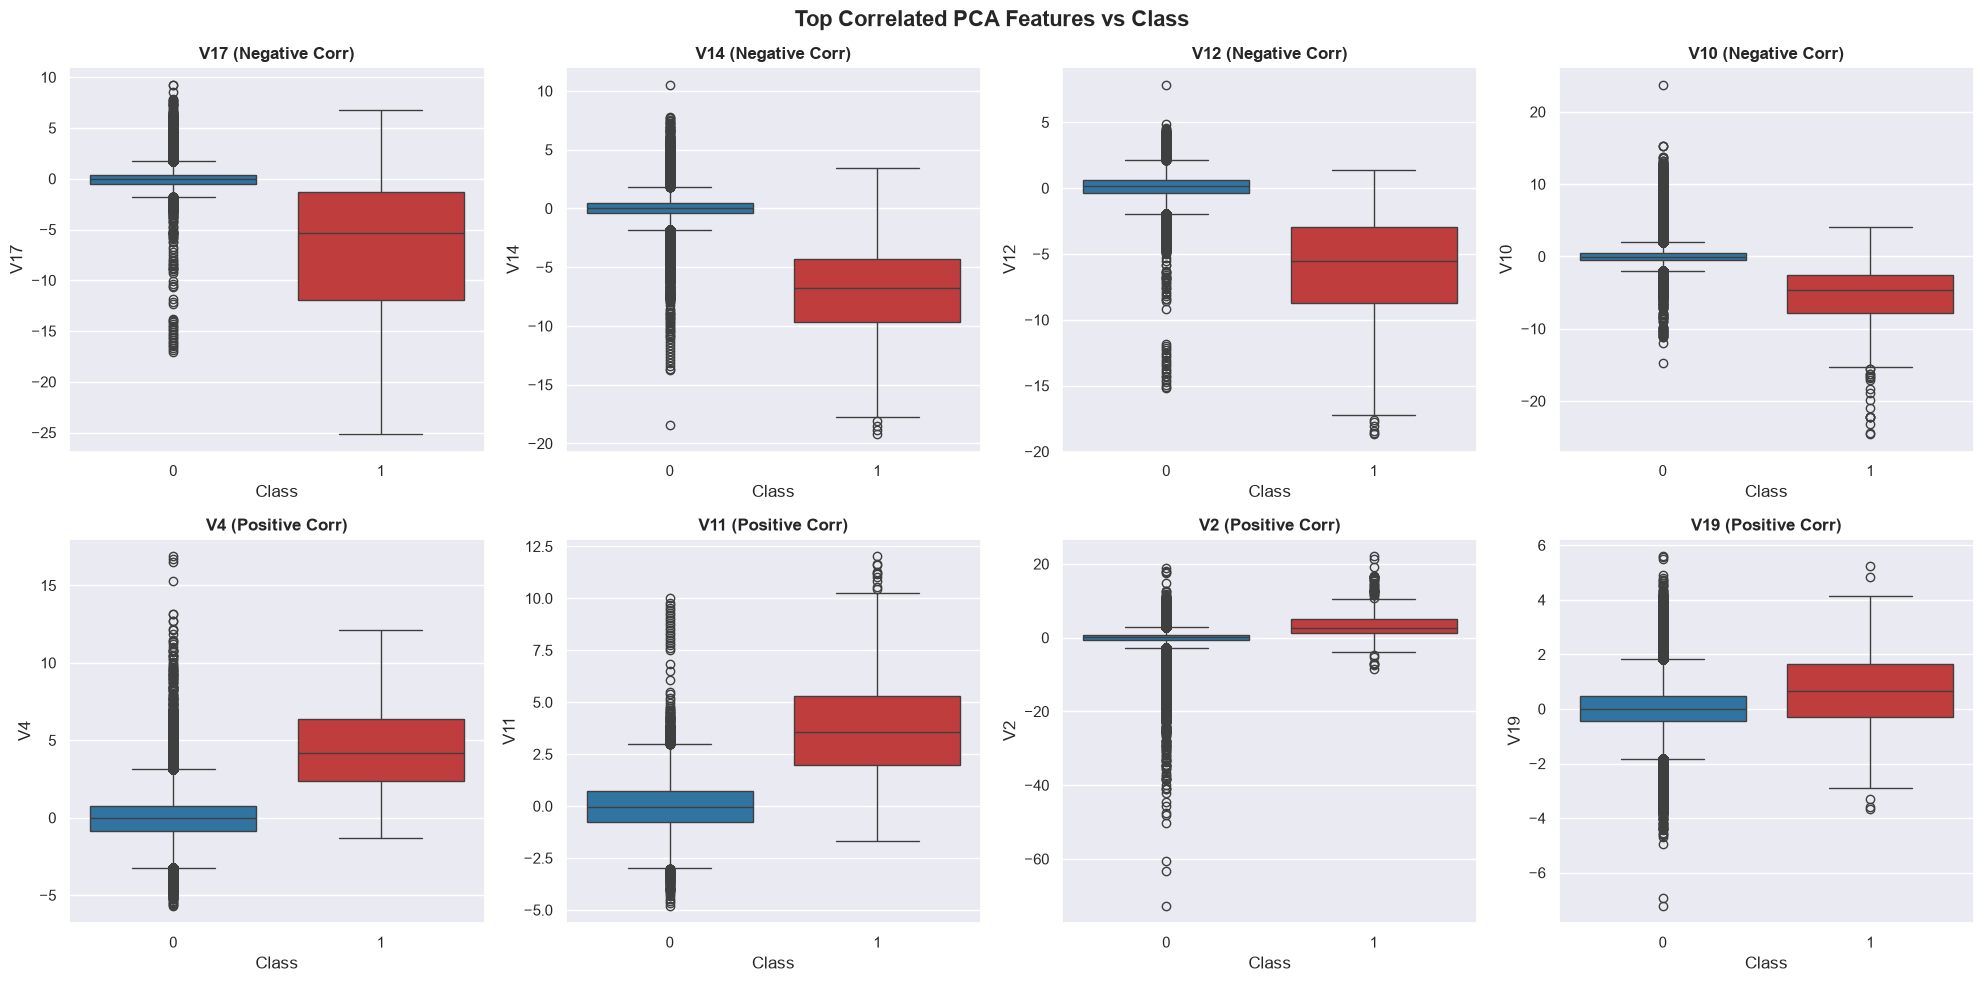

In [10]:
# Boxplots of Top Features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
top_neg = ['V17', 'V14', 'V12', 'V10']
top_pos = ['V4', 'V11', 'V2', 'V19']

for i, feat in enumerate(top_neg):
    sns.boxplot(x='Class', y=feat, hue='Class', data=df, ax=axes[0, i], palette=['#1f77b4', '#d62728'], legend=False)
    axes[0, i].set_title(f'{feat} (Negative Corr)', fontsize=12, fontweight='bold')

for i, feat in enumerate(top_pos):
    sns.boxplot(x='Class', y=feat, hue='Class', data=df, ax=axes[1, i], palette=['#1f77b4', '#d62728'], legend=False)
    axes[1, i].set_title(f'{feat} (Positive Corr)', fontsize=12, fontweight='bold')

plt.suptitle('Top Correlated PCA Features vs Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()